In [41]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import sem

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
HOME = os.path.expanduser('~')
root = os.path.join(HOME, 'schafkopf/pdall_test/')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [43]:
modes = ['ssc4', 'ssc5', 'ssc6', 'ssco']
gametypes = ['all', 'rufspiel', 'farbwenz', 'geier', 'wenz', 'farbsolo', 'allesolos']
# {-1: Zamgworfen, 0: 'Ramsch', 1: 'Rufspiel', 2: 'Farbwenz', 3: 'Geier', 4: 'Wenz', 5: 'Solo'}

In [44]:
yk, yl = {mode: dict() for mode in modes}, {mode: dict() for mode in modes}
for mode in modes:
    df = pd.read_parquet(os.path.join(root, f'pd0000_{mode}.parquet'))
    # print(df.player0_optimality[:10].values)
    for g, gametype in enumerate(gametypes):
        if gametype == 'all':
            dk = df[df.rule_kurze & (df.game_type > 0)]
            dl = df[~df.rule_kurze & (df.game_type > 0)]
        elif gametype == 'allesolos':
            dk = df[df.rule_kurze & (df.game_type > 1)]
            dl = df[~df.rule_kurze & (df.game_type > 1)]
        else:
            dk = df[df.rule_kurze & (df.game_type == g)]
            dl = df[~df.rule_kurze & (df.game_type == g)]
        yk[mode][gametype] = np.array([*dk.execution_times.tolist()])
        yl[mode][gametype] = np.array([*dl.execution_times.tolist()])
        print(f'[Kurze Karte, {mode}, {gametype}]: mean ± SE = {dk.execution_time.mean():.3f} ± {dk.execution_time.sem():.3f} sec (median={dk.execution_time.median():.3f} sec)')
        print(f'[Lange Karte, {mode}, {gametype}]: mean ± SE = {dl.execution_time.mean():.1f} ± {dl.execution_time.sem():.1f} sec (median={dl.execution_time.median():.1f} sec)')

[Kurze Karte, ssc4, all]: mean ± SE = 0.445 ± 0.003 sec (median=0.341 sec)
[Lange Karte, ssc4, all]: mean ± SE = 26.2 ± 0.4 sec (median=15.2 sec)
[Kurze Karte, ssc4, rufspiel]: mean ± SE = 0.423 ± 0.005 sec (median=0.321 sec)
[Lange Karte, ssc4, rufspiel]: mean ± SE = 23.2 ± 0.4 sec (median=14.0 sec)
[Kurze Karte, ssc4, farbwenz]: mean ± SE = 0.439 ± 0.008 sec (median=0.322 sec)
[Lange Karte, ssc4, farbwenz]: mean ± SE = 28.5 ± 1.7 sec (median=17.6 sec)
[Kurze Karte, ssc4, geier]: mean ± SE = 0.525 ± 0.010 sec (median=0.425 sec)
[Lange Karte, ssc4, geier]: mean ± SE = 54.0 ± 5.7 sec (median=36.6 sec)
[Kurze Karte, ssc4, wenz]: mean ± SE = 0.533 ± 0.008 sec (median=0.428 sec)
[Lange Karte, ssc4, wenz]: mean ± SE = 50.0 ± 2.1 sec (median=33.6 sec)
[Kurze Karte, ssc4, farbsolo]: mean ± SE = 0.390 ± 0.005 sec (median=0.286 sec)
[Lange Karte, ssc4, farbsolo]: mean ± SE = 21.3 ± 0.9 sec (median=11.8 sec)
[Kurze Karte, ssc4, allesolos]: mean ± SE = 0.454 ± 0.004 sec (median=0.349 sec)
[Lange 

In [45]:
yl['ssc5']['rufspiel'][:, 8:].mean(axis=0).sum()

0.4303944411701898

In [46]:
yl['ssco']['rufspiel'][:, 8:].mean(axis=0).sum()

0.4086713768951528

In [47]:
yl['ssc5']['rufspiel'][:, :9].mean(axis=0).sum() + yl['ssco']['rufspiel'][:, 9:].mean(axis=0).sum()

22.127677045056572

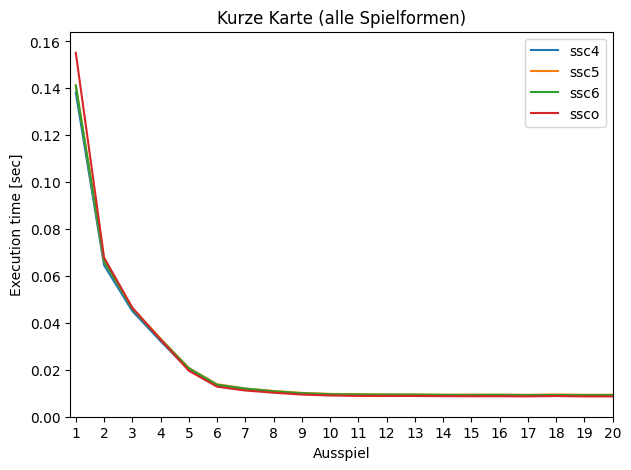

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yk[mode]['all'], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(20), y - sem(yk[mode]['all'], axis=0), y + sem(yk[mode]['all'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(20), range(1, 21));
plt.xlim(-0.2, 19)
plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Kurze Karte (alle Spielformen)')
plt.legend()

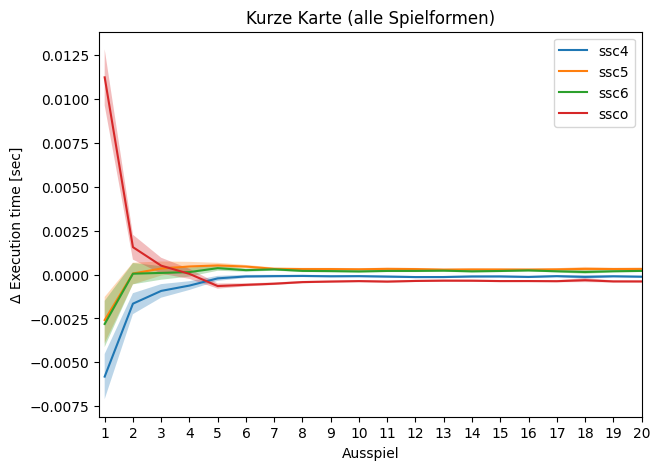

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yk[mode]['all'], axis=0) - np.mean([np.mean(yk[mode]['all'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(20), y - sem(yk[mode]['all'], axis=0), y + sem(yk[mode]['all'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(20), range(1, 21));
plt.xlim(-0.2, 19)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Kurze Karte (alle Spielformen)')
plt.legend()

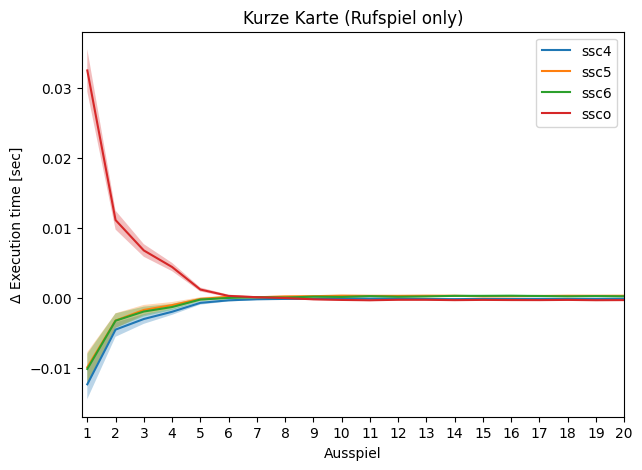

In [50]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yk[mode]['rufspiel'], axis=0) - np.mean([np.mean(yk[mode]['rufspiel'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(20), y - sem(yk[mode]['rufspiel'], axis=0), y + sem(yk[mode]['rufspiel'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(20), range(1, 21));
plt.xlim(-0.2, 19)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Kurze Karte (Rufspiel only)')
plt.legend()

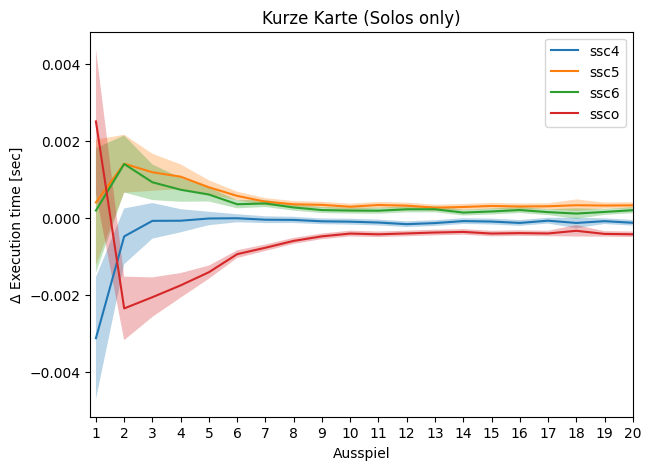

In [51]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yk[mode]['allesolos'], axis=0) - np.mean([np.mean(yk[mode]['allesolos'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(20), y - sem(yk[mode]['allesolos'], axis=0), y + sem(yk[mode]['allesolos'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(20), range(1, 21));
plt.xlim(-0.2, 19)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Kurze Karte (Solos only)')
plt.legend()

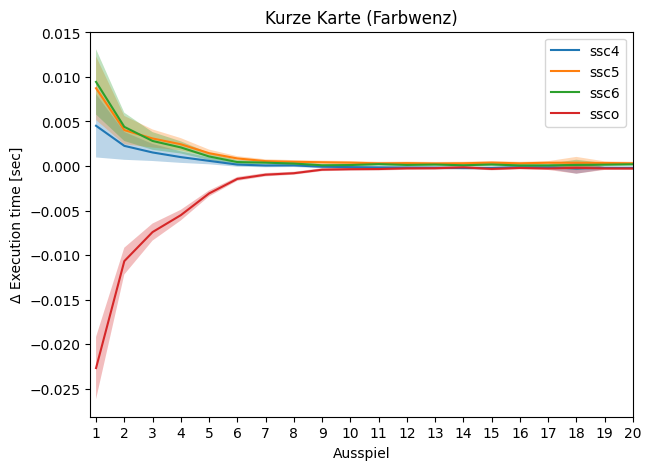

In [52]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yk[mode]['farbwenz'], axis=0) - np.mean([np.mean(yk[mode]['farbwenz'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(20), y - sem(yk[mode]['farbwenz'], axis=0), y + sem(yk[mode]['farbwenz'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(20), range(1, 21));
plt.xlim(-0.2, 19)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Kurze Karte (Farbwenz)')
plt.legend()

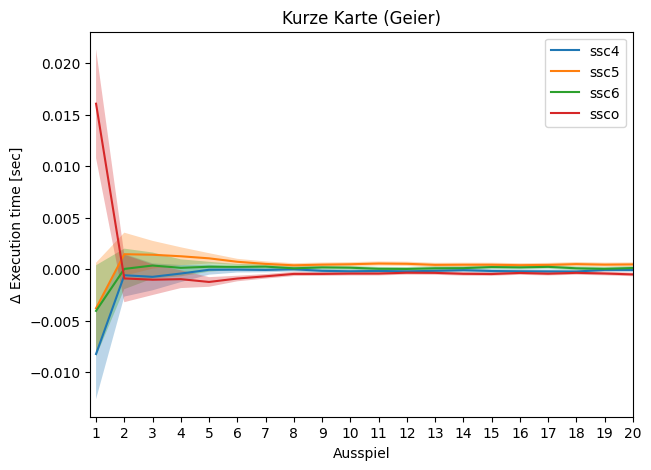

In [53]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yk[mode]['geier'], axis=0) - np.mean([np.mean(yk[mode]['geier'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(20), y - sem(yk[mode]['geier'], axis=0), y + sem(yk[mode]['geier'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(20), range(1, 21));
plt.xlim(-0.2, 19)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Kurze Karte (Geier)')
plt.legend()

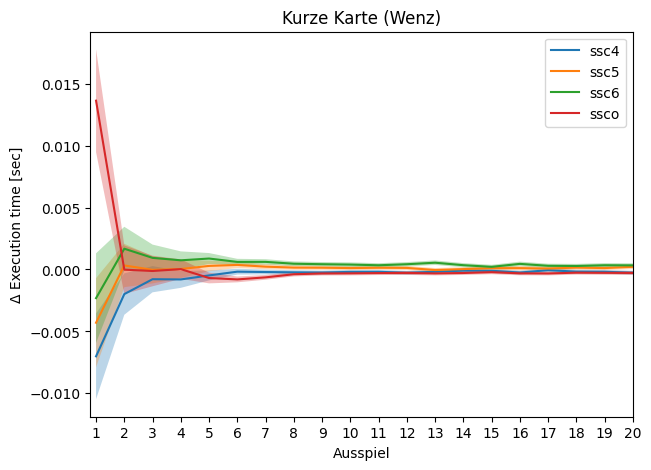

In [54]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yk[mode]['wenz'], axis=0) - np.mean([np.mean(yk[mode]['wenz'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(20), y - sem(yk[mode]['wenz'], axis=0), y + sem(yk[mode]['wenz'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(20), range(1, 21));
plt.xlim(-0.2, 19)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Kurze Karte (Wenz)')
plt.legend()

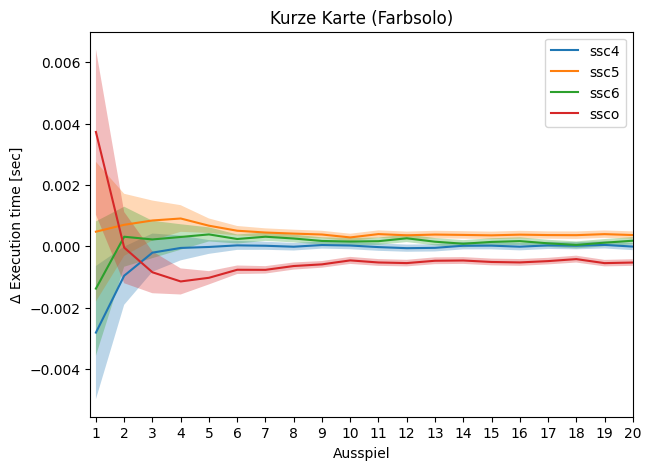

In [55]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yk[mode]['farbsolo'], axis=0) - np.mean([np.mean(yk[mode]['farbsolo'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(20), y - sem(yk[mode]['farbsolo'], axis=0), y + sem(yk[mode]['farbsolo'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(20), range(1, 21));
plt.xlim(-0.2, 19)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Kurze Karte (Farbsolo)')
plt.legend()

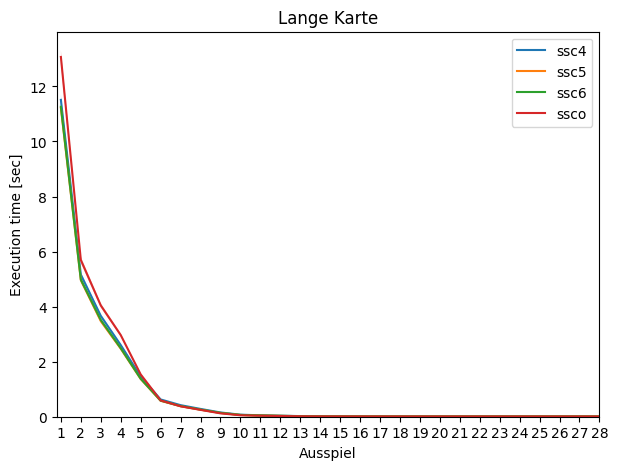

In [56]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yl[mode]['all'], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(28), y - sem(yl[mode]['all'], axis=0), y + sem(yl[mode]['all'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(28), range(1, 29));
plt.xlim(-0.2, 27)
plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte')
plt.legend()

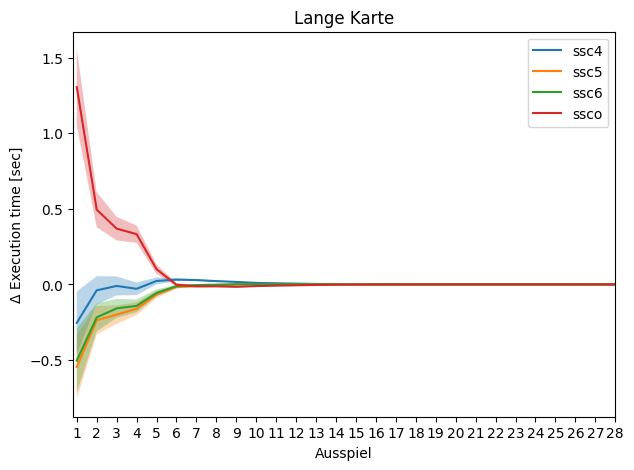

In [57]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yl[mode]['all'], axis=0) - np.mean([np.mean(yl[mode]['all'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(28), y - sem(yl[mode]['all'], axis=0), y + sem(yl[mode]['all'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(28), range(1, 29));
plt.xlim(-0.2, 27)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte')
plt.legend()

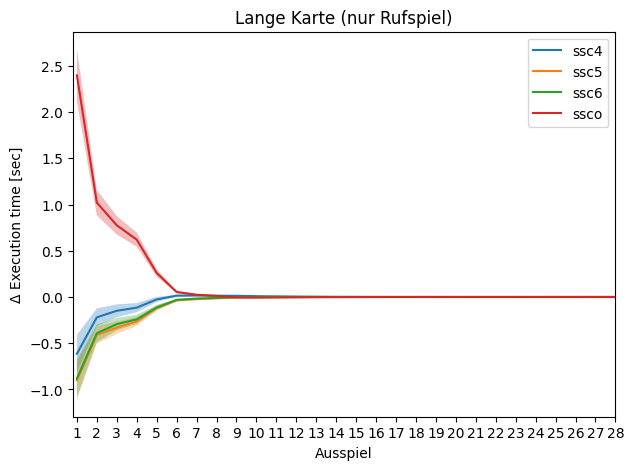

In [58]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yl[mode]['rufspiel'], axis=0) - np.mean([np.mean(yl[mode]['rufspiel'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(28), y - sem(yl[mode]['rufspiel'], axis=0), y + sem(yl[mode]['rufspiel'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(28), range(1, 29));
plt.xlim(-0.2, 27)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (nur Rufspiel)')
plt.legend()

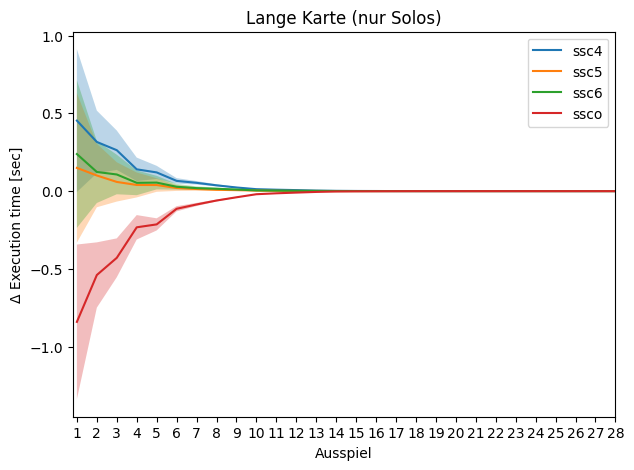

In [59]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yl[mode]['allesolos'], axis=0) - np.mean([np.mean(yl[mode]['allesolos'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(28), y - sem(yl[mode]['allesolos'], axis=0), y + sem(yl[mode]['allesolos'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(28), range(1, 29));
plt.xlim(-0.2, 27)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (nur Solos)')
plt.legend()

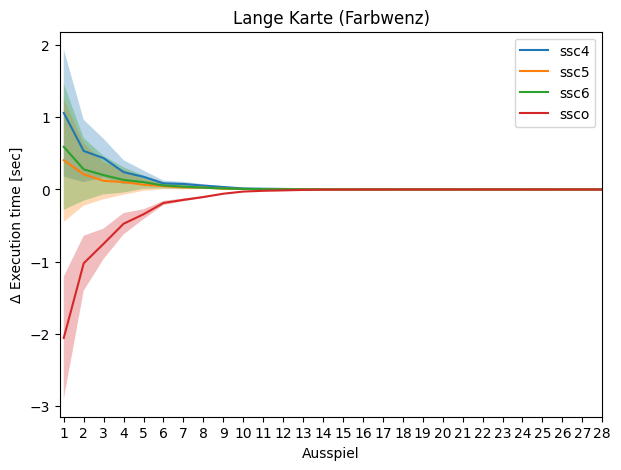

In [60]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yl[mode]['farbwenz'], axis=0) - np.mean([np.mean(yl[mode]['farbwenz'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(28), y - sem(yl[mode]['farbwenz'], axis=0), y + sem(yl[mode]['farbwenz'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(28), range(1, 29));
plt.xlim(-0.2, 27)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Farbwenz)')
plt.legend()

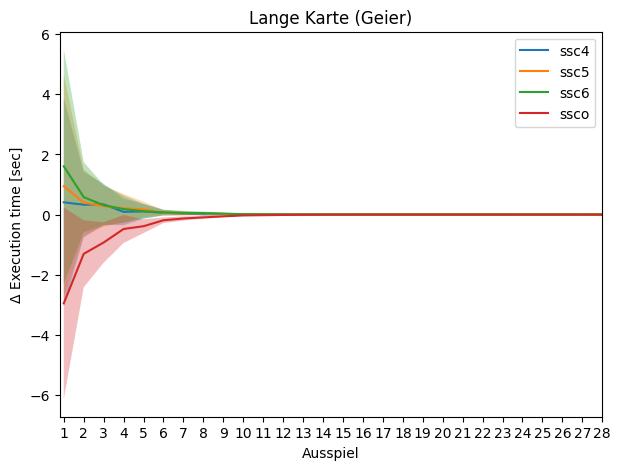

In [61]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yl[mode]['geier'], axis=0) - np.mean([np.mean(yl[mode]['geier'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(28), y - sem(yl[mode]['geier'], axis=0), y + sem(yl[mode]['geier'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(28), range(1, 29));
plt.xlim(-0.2, 27)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Geier)')
plt.legend()

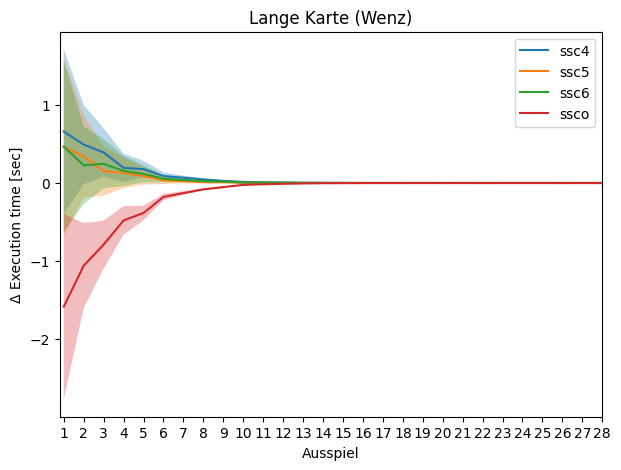

In [62]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yl[mode]['wenz'], axis=0) - np.mean([np.mean(yl[mode]['wenz'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(28), y - sem(yl[mode]['wenz'], axis=0), y + sem(yl[mode]['wenz'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(28), range(1, 29));
plt.xlim(-0.2, 27)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Wenz)')
plt.legend()

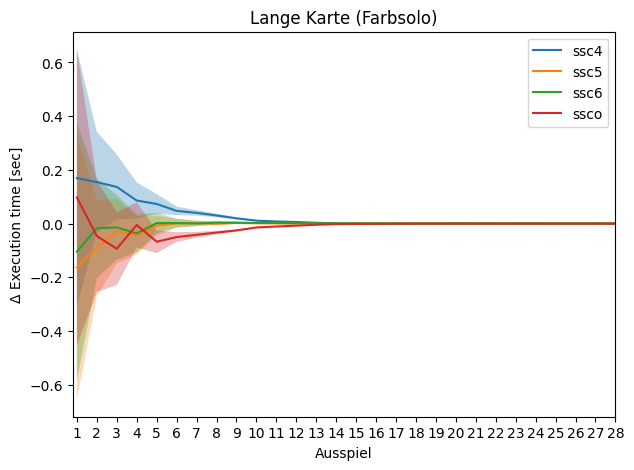

In [63]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = np.mean(yl[mode]['farbsolo'], axis=0) - np.mean([np.mean(yl[mode]['farbsolo'], axis=0) for mode in modes], axis=0)
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(28), y - sem(yl[mode]['farbsolo'], axis=0), y + sem(yl[mode]['farbsolo'], axis=0), color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(28), range(1, 29));
plt.xlim(-0.2, 27)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Farbsolo)')
plt.legend()

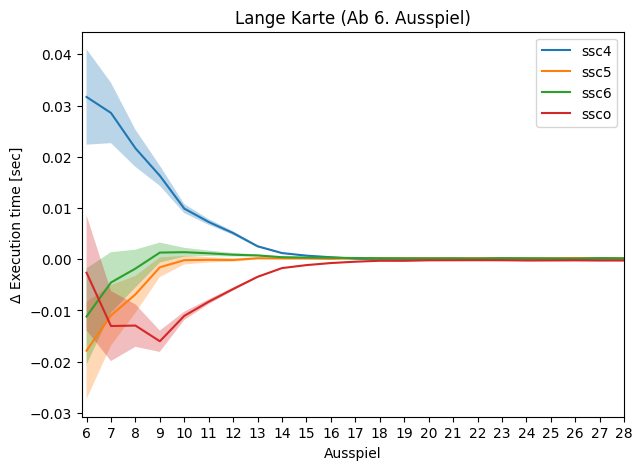

In [64]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = (np.mean(yl[mode]['all'], axis=0) - np.mean([np.mean(yl[mode]['all'], axis=0) for mode in modes], axis=0))[5:]
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(23), y - sem(yl[mode]['all'], axis=0)[5:], y + sem(yl[mode]['all'], axis=0)[5:], color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(23), range(6, 29));
plt.xlim(-0.2, 22)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Ab 6. Ausspiel)')
plt.legend()

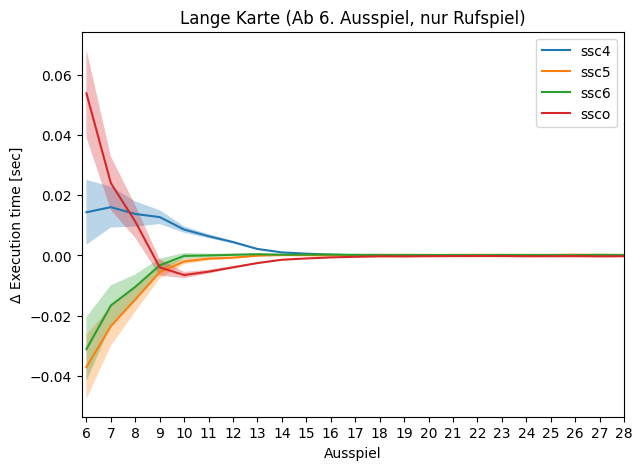

In [65]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = (np.mean(yl[mode]['rufspiel'], axis=0) - np.mean([np.mean(yl[mode]['rufspiel'], axis=0) for mode in modes], axis=0))[5:]
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(23), y - sem(yl[mode]['rufspiel'], axis=0)[5:], y + sem(yl[mode]['rufspiel'], axis=0)[5:], color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(23), range(6, 29));
plt.xlim(-0.2, 22)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Ab 6. Ausspiel, nur Rufspiel)')
plt.legend()

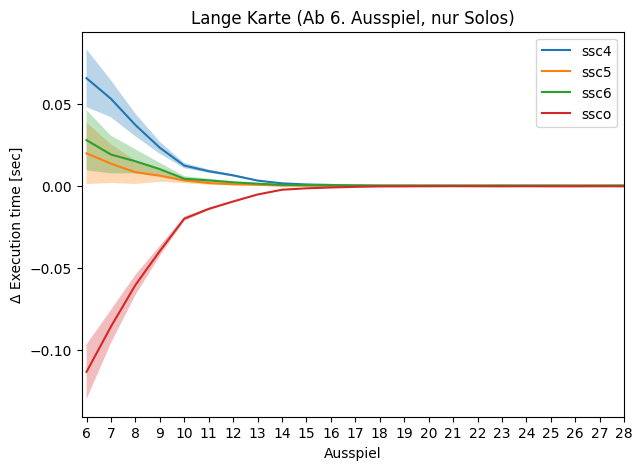

In [66]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = (np.mean(yl[mode]['allesolos'], axis=0) - np.mean([np.mean(yl[mode]['allesolos'], axis=0) for mode in modes], axis=0))[5:]
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(23), y - sem(yl[mode]['allesolos'], axis=0)[5:], y + sem(yl[mode]['allesolos'], axis=0)[5:], color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(23), range(6, 29));
plt.xlim(-0.2, 22)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Ab 6. Ausspiel, nur Solos)')
plt.legend()

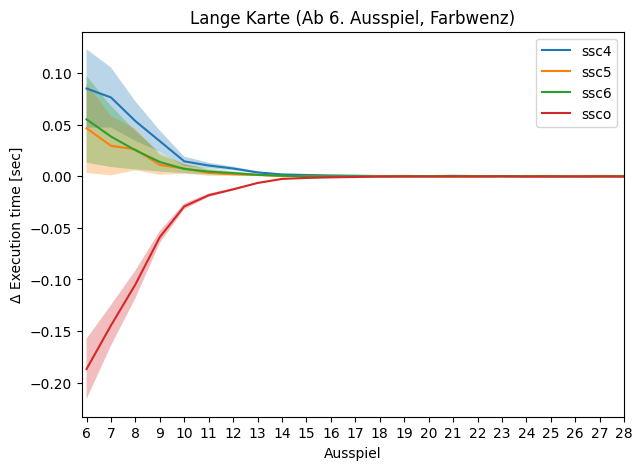

In [67]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = (np.mean(yl[mode]['farbwenz'], axis=0) - np.mean([np.mean(yl[mode]['farbwenz'], axis=0) for mode in modes], axis=0))[5:]
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(23), y - sem(yl[mode]['farbwenz'], axis=0)[5:], y + sem(yl[mode]['farbwenz'], axis=0)[5:], color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(23), range(6, 29));
plt.xlim(-0.2, 22)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Ab 6. Ausspiel, Farbwenz)')
plt.legend()

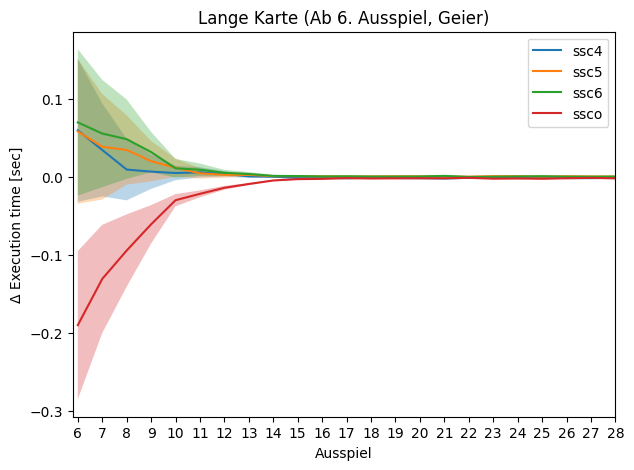

In [68]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = (np.mean(yl[mode]['geier'], axis=0) - np.mean([np.mean(yl[mode]['geier'], axis=0) for mode in modes], axis=0))[5:]
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(23), y - sem(yl[mode]['geier'], axis=0)[5:], y + sem(yl[mode]['geier'], axis=0)[5:], color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(23), range(6, 29));
plt.xlim(-0.2, 22)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Ab 6. Ausspiel, Geier)')
plt.legend()

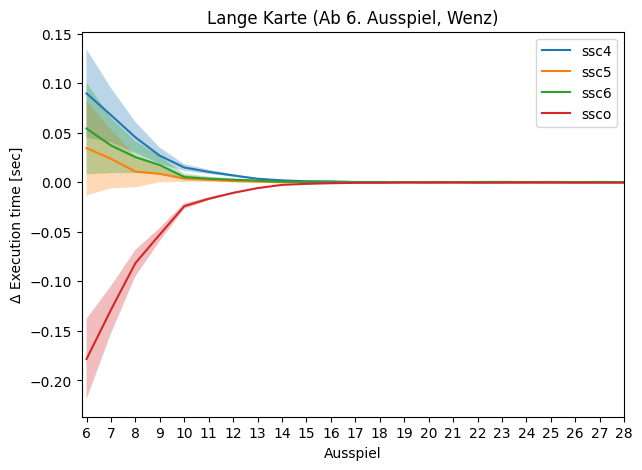

In [69]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = (np.mean(yl[mode]['wenz'], axis=0) - np.mean([np.mean(yl[mode]['wenz'], axis=0) for mode in modes], axis=0))[5:]
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(23), y - sem(yl[mode]['wenz'], axis=0)[5:], y + sem(yl[mode]['wenz'], axis=0)[5:], color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(23), range(6, 29));
plt.xlim(-0.2, 22)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Ab 6. Ausspiel, Wenz)')
plt.legend()

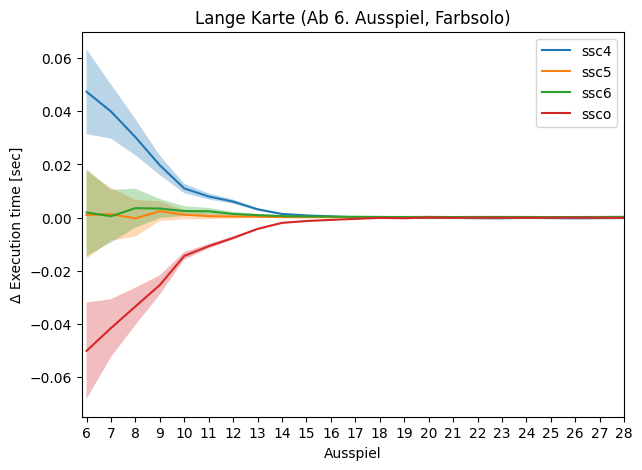

In [70]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, mode in enumerate(modes):
    y = (np.mean(yl[mode]['farbsolo'], axis=0) - np.mean([np.mean(yl[mode]['farbsolo'], axis=0) for mode in modes], axis=0))[5:]
    plt.plot(y, label=mode, color=colors[i])
    plt.fill_between(range(23), y - sem(yl[mode]['farbsolo'], axis=0)[5:], y + sem(yl[mode]['farbsolo'], axis=0)[5:], color=colors[i], alpha=0.3, ec='none')
plt.xticks(range(23), range(6, 29));
plt.xlim(-0.2, 22)
# plt.ylim(0, ax.get_ylim()[1])
plt.ylabel('Δ Execution time [sec]')
plt.xlabel('Ausspiel')
plt.title('Lange Karte (Ab 6. Ausspiel, Farbsolo)')
plt.legend()